<h2> Figure with results from residence time experiments</h2>

In [1]:
# Some imports to stop some annoying yellow underlines
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
import importlib

# Very important lines to run the setup notebooks!!!
%run do_plot_setup.ipynb
%run do_radical_count_setup.ipynb
get_cl_radical_budget = get_cl_radical_budget # Tautology to get rid of the yellow underlines
import cl2_utilities as cl2_utils
import process_cl2_logfile as process_cl2#This underline is unavoidable

# Extract some shared values that are used to facilitate plotting. Call 'display' on any of them to see their contents.
plot_default_properties = get_and_apply_plot_defaults() #Ignore yellow underline
line_default_properties = get_default_line_properties() #Ignore yellow underline
cl2_experiment_constants = get_cl2_experiment_constants() #Ignore yellow underline
(all_conversion_data,all_bypass_data) = get_experimental_data() #Ignore underline. These two dataframes have all the experimental results.

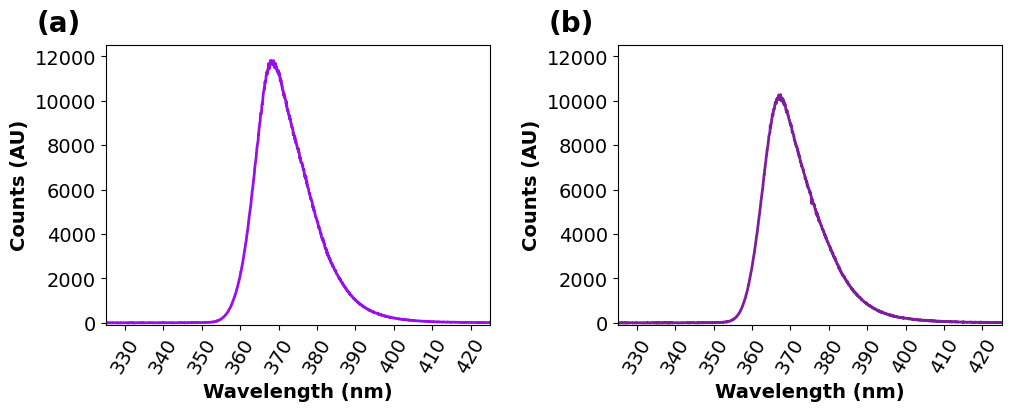

In [6]:
high_flux = pd.read_csv("./led_spectra/high-flux.txt",sep="\t", names=["Wavelength","Counts"], skiprows=14)
high_flux_bkg = pd.read_csv("./led_spectra/high-flux-baseline.txt",sep="\t", names=["Wavelength","Counts"], skiprows=14)
low_flux = pd.read_csv("./led_spectra/low-flux.txt",sep="\t", names=["Wavelength","Counts"], skiprows=14)
low_flux_bkg = pd.read_csv("./led_spectra/low-flux-baseline.txt",sep="\t", names=["Wavelength","Counts"], skiprows=14)

(fig, (ax_a, ax_b)) = plt.subplots(1,2,figsize=(10,4))
ax_a.text(-0.18,1.05, "(a)", transform=ax_a.transAxes, size=plot_default_properties['subplot_letter_size'], weight='bold')
ax_b.text(-0.18,1.05, "(b)", transform=ax_b.transAxes, size=plot_default_properties['subplot_letter_size'], weight='bold')
ax_a.plot(low_flux['Wavelength'], low_flux['Counts']-low_flux_bkg['Counts'],linewidth=2,color='xkcd:violet')
ax_b.plot(high_flux['Wavelength'], high_flux['Counts']-high_flux_bkg['Counts'],linewidth=2,color='xkcd:purple')

for ax in (ax_a, ax_b):
    ax.set_xlim(325,425)
    ax.set_ylim(-100,12500)
    ax.set_xticks(np.linspace(330,420,10))
    #ax.grid('both')
    ax.tick_params('x',rotation=60)
    ax.set_xlabel("Wavelength (nm)",weight='bold')
ax_a.set_ylabel("Counts (AU)",weight='bold')
ax_b.set_ylabel("\nCounts (AU)",weight='bold')

plt.savefig('exported_images/led_spectra.png', bbox_inches='tight',dpi=300)
plt.show()
pass
